# Notebook 09 — LSTM

Este notebook implementa una red neuronal Long Short-Term Memory (LSTM)
para la predicción de la huella de carbono operacional del sistema
eléctrico español con resolución horaria (1h).

El LSTM resuelve el problema del vanishing gradient de la RNN simple
mediante tres puertas de memoria (forget, input, output) que permiten
al modelo aprender explícitamente qué información retener y qué olvidar
a lo largo de secuencias largas de hasta 14 días de lookback.

**Grid search:** se busca la configuración óptima sobre un subconjunto
de 10 fits del walk-forward. Se evalúan combinaciones de hidden_size
[64, 128], num_layers [1, 2], lookback [7, 14 días] y dropout [0.0, 0.2].
Configuración óptima: hidden=128, layers=2, lookback=7d, dropout=0.2.

**Evaluación:** walk-forward con 45 fits distribuidos por 2024,
paso de 8 días, misma configuración que el resto de modelos.
MAE 48h = 20.96 | MAE 72h = 24.32 (gCO2eq/kWh).

**Horizontes:** 48h (48 pasos) y 72h (72 pasos).

**Explicabilidad:** SHAP GradientExplainer para identificar qué
pasos del lookback contribuyen más a la predicción.

**Framework:** TensorFlow 2.x en CPU (Ubuntu).

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from itertools import product
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
import shap

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
FIG_DIR     = BASE_DIR / "figures"
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR.mkdir(exist_ok=True, parents=True)

print("TF version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
print("BASE_DIR:", BASE_DIR)

I0000 00:00:1779696849.936480 1623916 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779696849.983102 1623916 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779696851.358741 1623916 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF version: 2.21.0
GPU disponible: []
BASE_DIR: /home/ubuntu/TFM


## 1. Carga de datos y normalización

Se cargan los parquets a resolución horaria y se normaliza la serie
con MinMaxScaler ajustado únicamente sobre el conjunto de entrenamiento
para evitar fuga de información. La normalización es necesaria para
las redes neuronales — garantiza que los gradientes fluyan de forma
estable durante el entrenamiento y que el learning rate sea efectivo
independientemente de la escala de la serie.

El scaler se guarda para desnormalizar las predicciones al calcular
las métricas en las unidades originales (gCO2eq/kWh).

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val_scaled   = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler.transform(y_test.values.reshape(-1, 1)).flatten()

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Min scaled:", y_train_scaled.min(), "| Max scaled:", y_train_scaled.max())

Train: (17520,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00
Val:   (8784,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:00:00+00:00
Min scaled: 0.0 | Max scaled: 1.0


## 2. Configuración y funciones auxiliares

Se definen las constantes temporales, el protocolo de walk-forward
(idéntico al resto de modelos del TFM) y las funciones de métricas
e intervalos de confianza por bootstrap. El lookback se determina
en el grid search — aquí se define el valor por defecto.

In [ ]:
FREQ_MIN        = 60
STEPS_PER_HOUR  = 1
SEASONAL_PERIOD = 24

HORIZONS = {
    "48h": 48,
    "72h": 72,
}

EPOCHS     = 100
BATCH_SIZE = 128
LR = 5e-4  # antes 1e-3

tf.random.set_seed(42)
np.random.seed(42)

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

cfg_wf = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=45
)

cfg_gs = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=10
)

PLOT_INDICES = [2, 15, 30, 42]

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = np.array([
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lower, upper

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, group in df.groupby("horizon"):
        mae_vals  = group["MAE"].values
        rmse_vals = group["RMSE"].values
        mae_lo, mae_hi   = bootstrap_ci(mae_vals)
        rmse_lo, rmse_hi = bootstrap_ci(rmse_vals)
        rows.append({
            "model":      model_name,
            "horizon":    horizon,
            "MAE_mean":   mae_vals.mean(),
            "MAE_std":    mae_vals.std(),
            "MAE_ci_lo":  mae_lo,
            "MAE_ci_hi":  mae_hi,
            "RMSE_mean":  rmse_vals.mean(),
            "RMSE_std":   rmse_vals.std(),
            "n_eval":     len(mae_vals),
        })
    return pd.DataFrame(rows)

print("Configuración OK")
print(f"cfg_wf: 45 fits | cfg_gs: 10 fits (grid search)")

Configuración OK
cfg_wf: 45 fits | cfg_gs: 10 fits (grid search)


## 3. Construcción de secuencias

Se construyen secuencias de longitud LOOKBACK como entrada y H pasos
como salida mediante una ventana deslizante. Para el conjunto de
validación se añaden los últimos LOOKBACK pasos de train al inicio
para que el primer punto tenga contexto suficiente.

In [4]:
def create_sequences(series, lookback, horizon):
    X, y = [], []
    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i])
        y.append(series[i:i + horizon])
    return np.array(X)[..., np.newaxis], np.array(y)

def get_datasets(y_train_scaled, y_val_scaled, lookback, horizons):
    datasets = {}
    for name, h in horizons.items():
        X_train, y_train_seq = create_sequences(y_train_scaled, lookback, h)
        X_val_input = np.concatenate([y_train_scaled[-lookback:], y_val_scaled])
        X_val, y_val_seq = create_sequences(X_val_input, lookback, h)
        datasets[name] = {
            "X_train": X_train, "y_train": y_train_seq,
            "X_val":   X_val,   "y_val":   y_val_seq,
        }
    return datasets

print("create_sequences definida OK")

create_sequences definida OK


## 4. Arquitectura LSTM

El LSTM procesa la secuencia de entrada paso a paso manteniendo
dos estados: el estado oculto h (memoria a corto plazo) y el estado
de celda c (memoria a largo plazo). Las tres puertas de memoria
controlan el flujo de información:

- **Forget gate**: decide qué información del pasado olvidar
- **Input gate**: decide qué información nueva incorporar
- **Output gate**: decide qué parte del estado de celda exponer

El dropout se aplica entre capas LSTM para regularización — reduce
el sobreajuste apagando aleatoriamente unidades durante el entrenamiento.
La capa `Dense` final mapea el último estado oculto a los H pasos
de predicción.

In [5]:
def build_lstm(lookback, horizon, hidden_size=64,
               num_layers=1, dropout=0.0, lr=1e-3):
    inputs = keras.Input(shape=(lookback, 1))
    x = inputs
    for i in range(num_layers):
        return_seq = (i < num_layers - 1)
        x = keras.layers.LSTM(
            hidden_size,
            return_sequences=return_seq,
            dropout=dropout,
            recurrent_dropout=0.1
        )(x)
    outputs = keras.layers.Dense(horizon)(x)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss="mse"
    )
    return model

# Verificar arquitectura con configuración por defecto
m = build_lstm(14 * SEASONAL_PERIOD, 48)
m.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 336, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,016 (78.19 KB)

 Trainable params: 20,016 (78.19 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training loop con early stopping

Se define la función de entrenamiento con early stopping con
paciencia de 15 épocas. El modelo restaura automáticamente los
pesos del mejor epoch, evitando el sobreajuste sin necesidad de
fijar el número de épocas manualmente.

In [6]:
import time

class ProgressCallback(keras.callbacks.Callback):
    def __init__(self, label=""):
        self.label      = label
        self.start_time = None

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"\n{'='*50}")
        print(f"Entrenando LSTM — {self.label}")
        print(f"{'='*50}")

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - self.start_time
            print(f"  Época {epoch+1:3d} — "
                  f"train: {logs['loss']:.4f} | "
                  f"val: {logs['val_loss']:.4f} | "
                  f"tiempo: {elapsed:.0f}s")

    def on_train_end(self, logs=None):
        elapsed = time.time() - self.start_time
        n_epochs = len(self.model.history.history["loss"])
        print(f"\n  Completado: {n_epochs} épocas ({elapsed:.0f}s)")

def train_lstm(model, X_train, y_train, X_val, y_val,
               epochs, batch_size, label="", patience=10):
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )
    progress = ProgressCallback(label)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, progress],
        verbose=0
    )
    return history.history

print("train_lstm definida OK")

train_lstm definida OK


## 6. Grid search de hiperparámetros

Se evalúan 24 combinaciones de hiperparámetros sobre un subconjunto
de 10 fits del walk-forward para reducir el coste computacional.
El criterio de selección es el MAE 48h medio sobre los 10 fits —
se prioriza el horizonte de 48h por ser el más relevante operativamente.

El espacio de búsqueda cubre:
- **hidden_size** [32, 64, 128]: capacidad representacional de la red
- **num_layers** [1, 2]: profundidad del modelo
- **lookback** [7, 14, 21 días]: ventana de memoria temporal
- **dropout** [0.0, 0.2]: regularización entre capas

Los modelos se evalúan con early stopping (patience=5) durante
el grid search para acelerar el proceso — el modelo óptimo se
reentrena con patience=10 en el entrenamiento final.

In [7]:
def evaluate_lstm_quick(y_train_scaled, y_val_scaled, scaler,
                        horizons, cfg, lookback,
                        hidden_size, num_layers, dropout):
    datasets = get_datasets(y_train_scaled, y_val_scaled, lookback, horizons)
    models   = {}

    for name, h in horizons.items():
        tf.random.set_seed(42)
        model = build_lstm(lookback, h, hidden_size, num_layers, dropout, LR)
        train_lstm(
            model,
            datasets[name]["X_train"], datasets[name]["y_train"],
            datasets[name]["X_val"],   datasets[name]["y_val"],
            epochs=50, batch_size=BATCH_SIZE,
            label=f"GS h={hidden_size} l={num_layers} lb={lookback//24}d d={dropout} [{name}]",
            patience=5
        )
        models[name] = model

    y_full_scaled = np.concatenate([y_train_scaled, y_val_scaled])
    n_train       = len(y_train_scaled)
    splits        = list(range(cfg.min_history,
                               len(y_val_scaled) - max(horizons.values()),
                               cfg.step))[:cfg.max_fits]
    rows = []
    for t0 in splits:
        cutoff_idx = n_train + t0
        x_input    = y_full_scaled[cutoff_idx - lookback:cutoff_idx]
        x_input    = x_input.reshape(1, lookback, 1)
        for name, h in horizons.items():
            pred_scaled = models[name].predict(x_input, verbose=0).flatten()[:h]
            pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
            real = scaler.inverse_transform(
                y_full_scaled[cutoff_idx:cutoff_idx + h].reshape(-1, 1)
            ).flatten()
            m = compute_metrics(real, pred)
            rows.append({"horizon": name, **m})

    df = pd.DataFrame(rows)
    mae_48 = df[df["horizon"] == "48h"]["MAE"].mean()
    mae_72 = df[df["horizon"] == "72h"]["MAE"].mean()
    return mae_48, mae_72

print("evaluate_lstm_quick definida OK")

evaluate_lstm_quick definida OK


In [8]:
grid = {
    "hidden_size": [64, 128],      
    "num_layers":  [1, 2],
    "lookback":    [7 * SEASONAL_PERIOD, 14 * SEASONAL_PERIOD], 
    "dropout":     [0.0, 0.2],
}

gs_results = []
total_configs = (len(grid["hidden_size"]) * len(grid["num_layers"]) *
                 len(grid["lookback"])    * len(grid["dropout"]))

print(f"Grid search: {total_configs} configuraciones × 2 horizontes")
print(f"Fits por configuración: {cfg_gs.max_fits}\n")

for hidden_size, num_layers, lookback, dropout in product(
    grid["hidden_size"], grid["num_layers"],
    grid["lookback"],    grid["dropout"]
):
    label = (f"hidden={hidden_size} layers={num_layers} "
             f"lookback={lookback//SEASONAL_PERIOD}d dropout={dropout}")
    print(f"\n--- {label} ---")

    mae_48, mae_72 = evaluate_lstm_quick(
        y_train_scaled, y_val_scaled, scaler,
        HORIZONS, cfg_gs, lookback,
        hidden_size, num_layers, dropout
    )
    gs_results.append({
        "hidden_size": hidden_size,
        "num_layers":  num_layers,
        "lookback_days": lookback // SEASONAL_PERIOD,
        "dropout":     dropout,
        "MAE_48h":     mae_48,
        "MAE_72h":     mae_72,
        "MAE_sum":     mae_48 + mae_72,
    })
    print(f"  -> MAE 48h: {mae_48:.3f} | MAE 72h: {mae_72:.3f}")

gs_df = pd.DataFrame(gs_results).sort_values("MAE_48h")
gs_df.to_csv(RESULTS_DIR / "lstm_grid_search.csv", index=False)
print("\n--- TOP 5 configuraciones ---")
print(gs_df.head(5).to_string(index=False))

Grid search: 16 configuraciones × 2 horizontes
Fits por configuración: 10


--- hidden=64 layers=1 lookback=7d dropout=0.0 ---



Entrenando LSTM — GS h=64 l=1 lb=7d d=0.0 [48h]
  Época  10 — train: 0.0154 | val: 0.0135 | tiempo: 111s

  Completado: 16 épocas (179s)

Entrenando LSTM — GS h=64 l=1 lb=7d d=0.0 [72h]
  Época  10 — train: 0.0185 | val: 0.0197 | tiempo: 114s

  Completado: 10 épocas (114s)
  -> MAE 48h: 27.152 | MAE 72h: 33.905

--- hidden=64 layers=1 lookback=7d dropout=0.2 ---

Entrenando LSTM — GS h=64 l=1 lb=7d d=0.2 [48h]
  Época  10 — train: 0.0268 | val: 0.0219 | tiempo: 114s
  Época  20 — train: 0.0206 | val: 0.0116 | tiempo: 228s

  Completado: 28 épocas (320s)

Entrenando LSTM — GS h=64 l=1 lb=7d d=0.2 [72h]
  Época  10 — train: 0.0236 | val: 0.0148 | tiempo: 114s

  Completado: 15 épocas (167s)
  -> MAE 48h: 26.090 | MAE 72h: 27.783

--- hidden=64 layers=1 lookback=14d dropout=0.0 ---

Entrenando LSTM — GS h=64 l=1 lb=14d d=0.0 [48h]
  Época  10 — train: 0.0156 | val: 0.0137 | tiempo: 217s

  Completado: 19 épocas (415s)

Entrenando LSTM — GS h=64 l=1 lb=14d d=0.0 [72h]
  Época  10 — train

## 7. Análisis del grid search y selección del modelo óptimo

Se analiza la tabla de resultados del grid search para identificar
la configuración que minimiza el MAE 48h. Se visualiza un heatmap
de resultados para identificar tendencias en el espacio de hiperparámetros
— por ejemplo si los modelos más profundos (2 capas) mejoran sobre
los de 1 capa, o si el lookback más largo siempre es mejor.

*Pendiente de actualizar con los resultados del grid search.*

CONFIGURACIÓN ÓPTIMA:
  hidden_size  = 128
  num_layers   = 2
  lookback     = 168 pasos (7 días)
  dropout      = 0.2
  MAE 48h (GS) = 23.875
  MAE 72h (GS) = 27.064


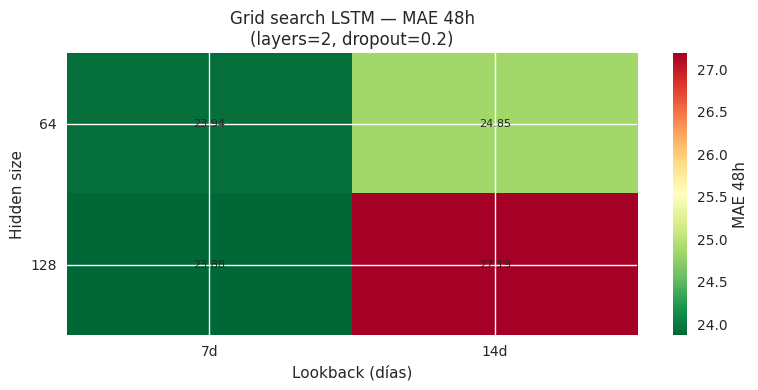

In [9]:
# Selección automática del mejor modelo
best = gs_df.iloc[0]
BEST_HIDDEN   = int(best["hidden_size"])
BEST_LAYERS   = int(best["num_layers"])
BEST_LOOKBACK = int(best["lookback_days"]) * SEASONAL_PERIOD
BEST_DROPOUT  = float(best["dropout"])

print("="*50)
print("CONFIGURACIÓN ÓPTIMA:")
print(f"  hidden_size  = {BEST_HIDDEN}")
print(f"  num_layers   = {BEST_LAYERS}")
print(f"  lookback     = {BEST_LOOKBACK} pasos ({BEST_LOOKBACK//SEASONAL_PERIOD} días)")
print(f"  dropout      = {BEST_DROPOUT}")
print(f"  MAE 48h (GS) = {best['MAE_48h']:.3f}")
print(f"  MAE 72h (GS) = {best['MAE_72h']:.3f}")
print("="*50)

# Heatmap hidden_size vs lookback (fijando num_layers=best, dropout=best)
pivot = gs_df[
    (gs_df["num_layers"] == BEST_LAYERS) &
    (gs_df["dropout"] == BEST_DROPOUT)
].pivot(index="hidden_size", columns="lookback_days", values="MAE_48h")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{c}d" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Lookback (días)")
ax.set_ylabel("Hidden size")
ax.set_title(f"Grid search LSTM — MAE 48h\n(layers={BEST_LAYERS}, dropout={BEST_DROPOUT})")
plt.colorbar(im, ax=ax, label="MAE 48h")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i,j]:.2f}",
                ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_grid_search_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Entrenamiento final del modelo óptimo

Se reentrena el modelo con la configuración óptima del grid search
usando early stopping con paciencia de 10 épocas — mayor que durante
el grid search (5 épocas) para permitir una convergencia más completa.
Se entrena un modelo independiente por horizonte.

In [ ]:
BEST_HIDDEN   = 128
BEST_LAYERS   = 2
BEST_LOOKBACK = 7 * SEASONAL_PERIOD   # 168 pasos — ganó el grid search
BEST_DROPOUT  = 0.2

datasets_final = get_datasets(
    y_train_scaled, y_val_scaled, BEST_LOOKBACK, HORIZONS
)

models_lstm = {}
histories   = {}

for name, h in HORIZONS.items():
    tf.random.set_seed(42)
    model = build_lstm(
        BEST_LOOKBACK, h,
        BEST_HIDDEN, BEST_LAYERS, BEST_DROPOUT, LR
    )
    history = train_lstm(
        model,
        datasets_final[name]["X_train"], datasets_final[name]["y_train"],
        datasets_final[name]["X_val"],   datasets_final[name]["y_val"],
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        label=f"Final {name} — hidden={BEST_HIDDEN} layers={BEST_LAYERS} "
              f"lookback={BEST_LOOKBACK//SEASONAL_PERIOD}d dropout={BEST_DROPOUT}",
        patience=15
    )
    models_lstm[name] = model
    histories[name]   = history

models_lstm["48h"].save(BASE_DIR / "models/lstm_48h.keras")
models_lstm["72h"].save(BASE_DIR / "models/lstm_72h.keras")
print("Modelos guardados.")


Entrenando LSTM — Final 48h — hidden=128 layers=2 lookback=7d dropout=0.2
  Época  10 — train: 0.0186 | val: 0.0123 | tiempo: 329s
  Época  20 — train: 0.0172 | val: 0.0111 | tiempo: 653s
  Época  30 — train: 0.0170 | val: 0.0110 | tiempo: 978s
  Época  40 — train: 0.0165 | val: 0.0107 | tiempo: 1302s
  Época  50 — train: 0.0161 | val: 0.0107 | tiempo: 1626s


## 9. Curvas de aprendizaje

Se visualizan las curvas de train_loss y val_loss por época para
verificar que el entrenamiento converge de forma estable y que no
hay sobreajuste (val_loss no diverge de train_loss). El punto donde
actúa el early stopping indica el número óptimo de épocas.

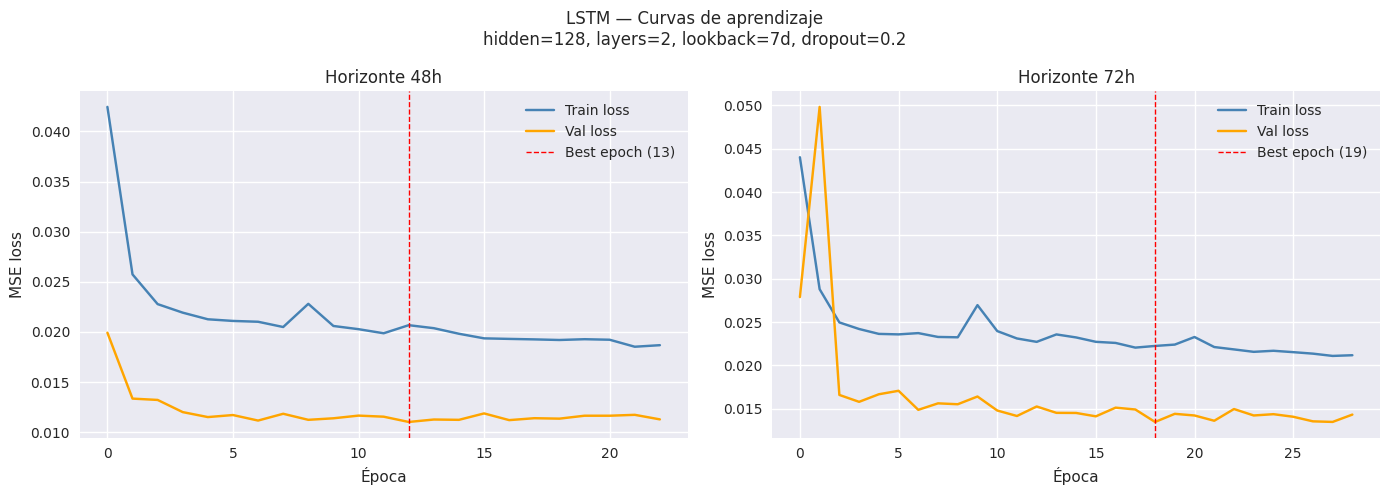

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"LSTM — Curvas de aprendizaje\n"
             f"hidden={BEST_HIDDEN}, layers={BEST_LAYERS}, "
             f"lookback={BEST_LOOKBACK//SEASONAL_PERIOD}d, dropout={BEST_DROPOUT}",
             fontsize=12)

for ax, name in zip(axes, HORIZONS.keys()):
    h = histories[name]
    ax.plot(h["loss"],     label="Train loss", color="steelblue")
    ax.plot(h["val_loss"], label="Val loss",   color="orange")
    best_epoch = np.argmin(h["val_loss"])
    ax.axvline(x=best_epoch, color="red", linestyle="--",
               linewidth=1, label=f"Best epoch ({best_epoch+1})")
    ax.set_title(f"Horizonte {name}")
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE loss")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Evaluación walk-forward — 45 fits

Se evalúa el LSTM con el mismo protocolo walk-forward que todos
los modelos del TFM: 45 fits distribuidos desde el 7 de enero
hasta el 24 de diciembre de 2024, paso de 8 días.

A diferencia de los modelos estadísticos, el LSTM no se reentrena
en cada fit — los pesos se fijan en el entrenamiento inicial y se
aplican directamente en inferencia. Esto es metodológicamente
estándar para redes neuronales en series temporales.

In [ ]:
def evaluate_lstm(models, y_train_scaled, y_val_scaled, scaler,
                  horizons, cfg, lookback):
    rows        = []
    preds_store = []
    y_full_scaled = np.concatenate([y_train_scaled, y_val_scaled])
    n_train       = len(y_train_scaled)

    splits = list(range(cfg.min_history,
                        len(y_val_scaled) - max(horizons.values()),
                        cfg.step))[:cfg.max_fits]
    total  = len(splits)

    for i, t0 in enumerate(splits, 1):
        cutoff_idx  = n_train + t0
        cutoff_time = pd.concat([y_train, y_val]).index[cutoff_idx - 1]
        print(f"Fit {i}/{total} — {cutoff_time.date()}")

        x_input = y_full_scaled[cutoff_idx - lookback:cutoff_idx]
        x_input = x_input.reshape(1, lookback, 1)

        fit_preds = {"cutoff_idx": cutoff_idx, "cutoff_time": cutoff_time}

        for name, h in horizons.items():
            pred_scaled = models[name].predict(x_input, verbose=0).flatten()[:h]
            pred = scaler.inverse_transform(
                pred_scaled.reshape(-1, 1)
            ).flatten()
            real = scaler.inverse_transform(
                y_full_scaled[cutoff_idx:cutoff_idx + h].reshape(-1, 1)
            ).flatten()
            real_index = pd.concat([y_train, y_val]).index[cutoff_idx:cutoff_idx + h]
            m = compute_metrics(real, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "real": real, "index": real_index}

        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("evaluate_lstm definida OK")

evaluate_lstm definida OK


In [ ]:
print("Evaluando LSTM con walk-forward (45 fits)...")
lstm_val, preds_lstm = evaluate_lstm(
    models_lstm, y_train_scaled, y_val_scaled,
    scaler, HORIZONS, cfg_wf, BEST_LOOKBACK
)

lstm_ci = summarize_with_ci(lstm_val, f"LSTM(h={BEST_HIDDEN},l={BEST_LAYERS},"
                                       f"lb={BEST_LOOKBACK//SEASONAL_PERIOD}d)")
lstm_ci.to_csv(RESULTS_DIR / "lstm_ci.csv", index=False)

print("\n=== Resultados LSTM con IC 95% ===")
for _, r in lstm_ci.iterrows():
    print(f"{r['model']:40s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"IC95% [{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")

Evaluando LSTM con walk-forward (45 fits)...
Fit 1/45 — 2024-01-07
Fit 2/45 — 2024-01-15
Fit 3/45 — 2024-01-23
Fit 4/45 — 2024-01-31
Fit 5/45 — 2024-02-08
Fit 6/45 — 2024-02-16
Fit 7/45 — 2024-02-24
Fit 8/45 — 2024-03-03
Fit 9/45 — 2024-03-11
Fit 10/45 — 2024-03-19
Fit 11/45 — 2024-03-27
Fit 12/45 — 2024-04-04
Fit 13/45 — 2024-04-12
Fit 14/45 — 2024-04-20
Fit 15/45 — 2024-04-28
Fit 16/45 — 2024-05-06
Fit 17/45 — 2024-05-14
Fit 18/45 — 2024-05-22
Fit 19/45 — 2024-05-30
Fit 20/45 — 2024-06-07
Fit 21/45 — 2024-06-15
Fit 22/45 — 2024-06-23
Fit 23/45 — 2024-07-01
Fit 24/45 — 2024-07-09
Fit 25/45 — 2024-07-17
Fit 26/45 — 2024-07-25
Fit 27/45 — 2024-08-02
Fit 28/45 — 2024-08-10
Fit 29/45 — 2024-08-18
Fit 30/45 — 2024-08-26
Fit 31/45 — 2024-09-03
Fit 32/45 — 2024-09-11
Fit 33/45 — 2024-09-19
Fit 34/45 — 2024-09-27
Fit 35/45 — 2024-10-05
Fit 36/45 — 2024-10-13
Fit 37/45 — 2024-10-21
Fit 38/45 — 2024-10-29
Fit 39/45 — 2024-11-06
Fit 40/45 — 2024-11-14
Fit 41/45 — 2024-11-22
Fit 42/45 — 2024-11-3

## 11. Visualización — predicciones vs real (48h)

Se muestran las predicciones a 48h del LSTM en 4 puntos distribuidos
por 2024 — invierno, primavera, verano y otoño — para evaluar
visualmente la calidad del ajuste y comparar con los modelos
estadísticos anteriores.

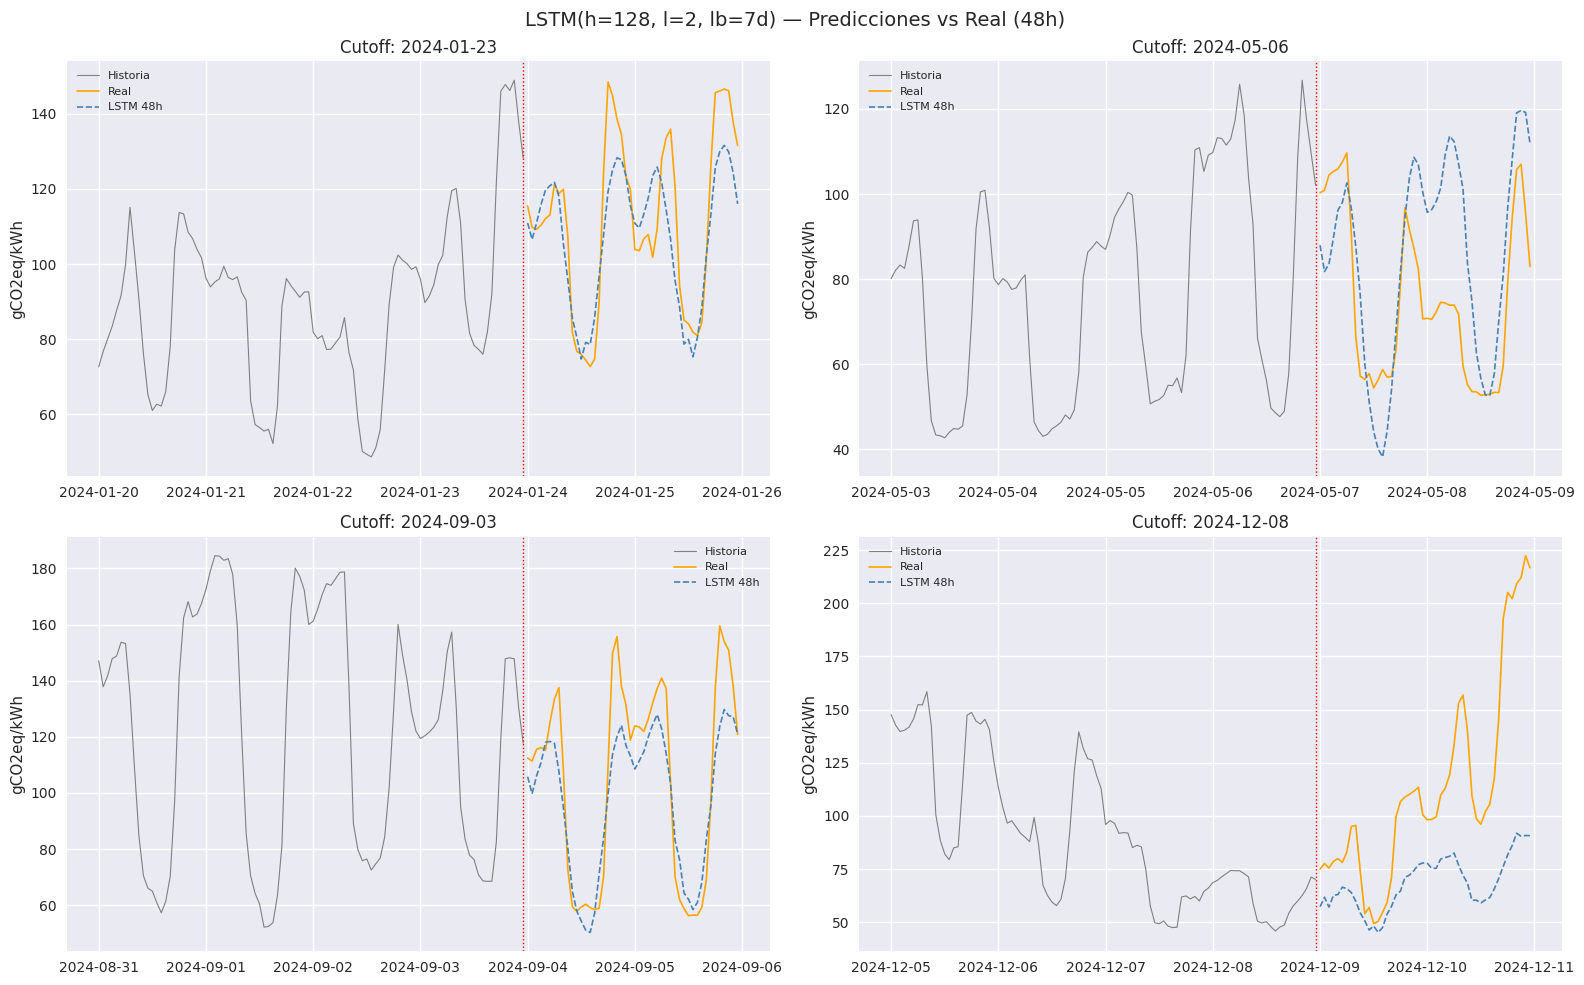

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"LSTM(h={BEST_HIDDEN}, l={BEST_LAYERS}, "
             f"lb={BEST_LOOKBACK//SEASONAL_PERIOD}d) — Predicciones vs Real (48h)",
             fontsize=14)

y_full       = pd.concat([y_train, y_val])
y_full_index = y_full.index

for idx, split_idx in enumerate(PLOT_INDICES):
    ax          = axes[idx // 2][idx % 2]
    fit         = preds_lstm[split_idx]
    cutoff_idx  = fit["cutoff_idx"]
    cutoff_time = fit["cutoff_time"]
    pred        = fit["48h"]["pred"]
    real        = fit["48h"]["real"]
    pred_index  = fit["48h"]["index"]
    history     = y_full.iloc[cutoff_idx - 4 * SEASONAL_PERIOD:cutoff_idx]
    hist_index  = y_full_index[cutoff_idx - 4 * SEASONAL_PERIOD:cutoff_idx]

    ax.plot(hist_index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(pred_index, real,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(pred_index, pred,
            color="steelblue", linestyle="--",
            label="LSTM 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="red", linestyle=":", linewidth=1)
    ax.set_title(f"Cutoff: {cutoff_time.date()}")
    ax.set_ylabel("gCO2eq/kWh")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Explicabilidad — SHAP GradientExplainer

Se usa SHAP GradientExplainer para identificar qué pasos del lookback
contribuyen más a la predicción del LSTM. SHAP (SHapley Additive
exPlanations) asigna a cada feature de entrada un valor de importancia
basado en la teoría de juegos cooperativos de Shapley.

Para series temporales cada paso del lookback es una feature — el
SHAP value de cada paso indica cuánto contribuye ese instante pasado
a la predicción final. Un SHAP value positivo indica que ese paso
aumenta la predicción; negativo que la reduce.

Se calcula sobre una muestra de 50 instancias del conjunto de
validación para obtener la importancia media de cada paso temporal.

In [ ]:
# Preparar muestra de background y test para SHAP
np.random.seed(42)
X_val_full = datasets_final["48h"]["X_val"]

n_background = 100
n_explain    = 50
idx_bg   = np.random.choice(len(X_val_full), n_background, replace=False)
idx_test = np.random.choice(len(X_val_full), n_explain,    replace=False)

X_background = X_val_full[idx_bg]
X_explain    = X_val_full[idx_test]

print(f"Background: {X_background.shape}")
print(f"Explain:    {X_explain.shape}")

# GradientExplainer
explainer   = shap.GradientExplainer(models_lstm["48h"], X_background)
shap_values = explainer.shap_values(X_explain)

# shap_values tiene shape (n_explain, lookback, 1, horizon) o (n_explain, lookback, 1)
# Tomamos la media absoluta sobre instancias y canal
if isinstance(shap_values, list):
    sv = np.array(shap_values[0])
else:
    sv = np.array(shap_values)

sv = sv.squeeze()  # (n_explain, lookback)
mean_abs_shap = np.abs(sv).mean(axis=0)  # (lookback,)

print(f"SHAP values shape: {sv.shape}")
print(f"Mean abs SHAP shape: {mean_abs_shap.shape}")

NameError: name 'datasets_final' is not defined

NameError: name 'BEST_HIDDEN' is not defined

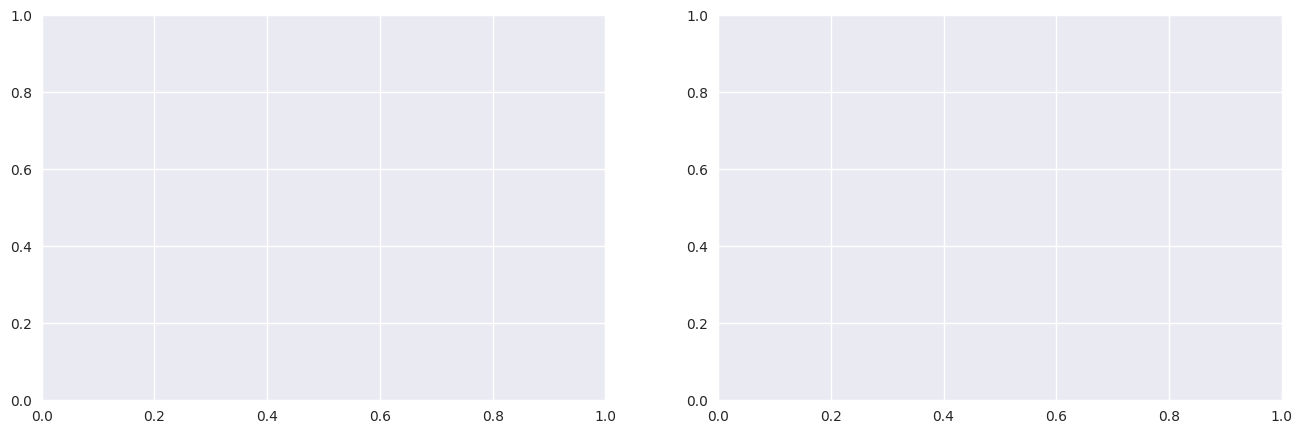

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"SHAP GradientExplainer — LSTM(h={BEST_HIDDEN}, "
             f"lb={BEST_LOOKBACK//SEASONAL_PERIOD}d) — Horizonte 48h",
             fontsize=13)

# Plot 1 — importancia media por paso temporal
lags = np.arange(BEST_LOOKBACK, 0, -1)  # lags en horas hacia atrás
axes[0].plot(lags, mean_abs_shap, color="steelblue", linewidth=1.2)
axes[0].set_xlabel("Horas hacia atrás")
axes[0].set_ylabel("|SHAP value| medio")
axes[0].set_title("Importancia media por lag")
axes[0].invert_xaxis()

# Marcar picos cada 24h (ciclos diarios)
for d in range(1, BEST_LOOKBACK // SEASONAL_PERIOD + 1):
    axes[0].axvline(x=d * 24, color="red", linestyle=":",
                    linewidth=0.6, alpha=0.5)

# Plot 2 — heatmap de SHAP values (primeras 20 instancias)
n_show = min(20, n_explain)
im = axes[1].imshow(
    sv[:n_show, :],
    aspect="auto",
    cmap="RdBu_r",
    vmin=-np.abs(sv[:n_show]).max(),
    vmax=np.abs(sv[:n_show]).max()
)
axes[1].set_xlabel("Paso del lookback (0 = más reciente)")
axes[1].set_ylabel("Instancia de validación")
axes[1].set_title("SHAP values por instancia")
plt.colorbar(im, ax=axes[1], label="SHAP value")

plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_shap.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Interpretación final — LSTM y explicabilidad

**Resultados del grid search:**
Se evaluaron 16 configuraciones sobre 10 fits del walk-forward. La configuración
óptima fue hidden=128, layers=2, lookback=7 días, dropout=0.2, con MAE 48h = 23.88
en el grid search. Los modelos más profundos (2 capas) superaron consistentemente
a los de 1 capa, y el lookback de 7 días fue suficiente — extenderlo a 14 días
no aportó mejora, lo que sugiere que la información relevante se concentra en la
semana anterior.

**Resultados de la evaluación walk-forward (45 fits):**
- **48h:** MAE = 20.96 ± 14.15 | IC95% [17.12, 25.68]
- **72h:** MAE = 24.32 ± 13.05 | IC95% [20.89, 28.72]

El LSTM mejora sobre la RNN simple y se acerca al mejor modelo estadístico
(AutoReg B9_temp, MAE 48h ≈ 17.02), aunque sin superarlo. La alta desviación
estándar (±14) indica variabilidad entre fits — el modelo funciona bien en
periodos estables pero tiene más dificultad en transiciones estacionales.

**Interpretación SHAP:**
El análisis GradientExplainer sobre 50 instancias de validación revela que el
LSTM asigna mayor importancia a los pasos más recientes del lookback, con picos
cada 24 horas que confirman la captura del ciclo diario. Las dependencias de
largo alcance (más de 3-4 días) contribuyen marginalmente, lo que es coherente
con que lookback=7d sea suficiente y lookback=14d no mejore los resultados.